In [2]:
# IMPORT LIBRARIES
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"          # hide INFO/WARNING + XLA autotune spam
os.environ.setdefault("TF_USE_LEGACY_KERAS", "0")
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Input,
    BatchNormalization, Dropout, Activation,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

# --- Hardware: enable GPU memory growth + mixed precision (big speed-up) ---
# If this prints "GPUs: []" you are on CPU -> turn on the Kaggle GPU accelerator
# (Settings -> Accelerator -> GPU) and Restart & Run All. CPU is ~50x slower.
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
USE_MIXED_PRECISION = len(gpus) > 0
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
print("GPUs:", [g.name for g in gpus], "| mixed precision:", USE_MIXED_PRECISION)


TensorFlow: 2.20.0
GPUs: ['/physical_device:GPU:0', '/physical_device:GPU:1'] | mixed precision: True


In [3]:
# DATASET PATHS  (DFUTissue precise masks + DFUC2020 bbox pseudo-masks)
# DFUC2021 is a *classification* dataset (none/infection/ischaemia/both) with no
# localization, so it cannot supervise a segmentation model -> it belongs to
# Model 3 (infection/pus), not Model 1. We use it here only as extra unlabeled
# images for the int8 representative dataset (see TFLite export cell).
def first_existing(*paths, find=None):
    # 1) try the explicit candidates
    for p in paths:
        if p and os.path.exists(p):
            return p
    # 2) fallback: auto-discover under /kaggle/input by matching the path tail,
    #    so a slightly-wrong dataset slug still resolves (e.g. .../Images/TrainVal)
    if find:
        for root in ("/kaggle/input", "."):
            hits = [h for h in glob(os.path.join(root, "**", find), recursive=True)
                    if os.path.exists(h)]
            if hits:
                return sorted(hits, key=len)[0]
    return None

# --- DFUTissue: precise pixel masks (primary segmentation labels) ---
DFUTISSUE_IMG_DIR = first_existing(
    "DFUTissueSegNet-main/DFUTissue/Labeled/Original/Images/TrainVal",
    "/kaggle/input/datasets/ibrahimshehada/dfutissue/DFUTissue/Labeled/Original/Images/TrainVal",
    find="DFUTissue/Labeled/Original/Images/TrainVal",
)
DFUTISSUE_MASK_DIR = first_existing(
    "DFUTissueSegNet-main/DFUTissue/Labeled/Original/Annotations/TrainVal",
    "/kaggle/input/datasets/ibrahimshehada/dfutissue/DFUTissue/Labeled/Original/Annotations/TrainVal",
    find="DFUTissue/Labeled/Original/Annotations/TrainVal",
)

# --- DFUC2020: bounding boxes -> rectangular pseudo-masks (weak labels) ---
DFUC2020_IMG_DIR = first_existing(
    "DFUC2020/train",
    "/kaggle/input/datasets/ibrahimshehada/dfuc2020/DFUC2020/DFUC2020/train",
    find="DFUC2020/train",
)
DFUC2020_CSV = first_existing(
    "groundtruth_DFUC2020_trainset.csv",
    "/kaggle/input/datasets/ibrahimshehada/dfuc2020/groundtruth_DFUC2020_trainset.csv",
    find="groundtruth_DFUC2020_trainset.csv",
)

# --- DFUC2021: extra images (used only for int8 calibration) ---
DFUC2021_IMG_DIR = first_existing(
    "DFUC2021/DFUC2021_train",
    "/kaggle/input/datasets/ibrahimshehada/dfuc2021/DFUC2021/DFUC2021_train",
    find="DFUC2021_train",
)

print("DFUTissue images :", DFUTISSUE_IMG_DIR)
print("DFUTissue masks  :", DFUTISSUE_MASK_DIR)
print("DFUC2020 images  :", DFUC2020_IMG_DIR)
print("DFUC2020 boxes   :", DFUC2020_CSV)
print("DFUC2021 images  :", DFUC2021_IMG_DIR)

assert DFUTISSUE_IMG_DIR and DFUTISSUE_MASK_DIR, \
    "DFUTissue not found -- check the dataset is attached and the path/slug is right."


DFUTissue images : /kaggle/input/datasets/ibrahimshehada/dfutissue/DFUTissue/Labeled/Original/Images/TrainVal
DFUTissue masks  : /kaggle/input/datasets/ibrahimshehada/dfutissue/DFUTissue/Labeled/Original/Annotations/TrainVal
DFUC2020 images  : /kaggle/input/datasets/ibrahimshehada/dfuc2020/DFUC2020/DFUC2020/train
DFUC2020 boxes   : /kaggle/input/datasets/ibrahimshehada/dfuc2020/groundtruth_DFUC2020_trainset.csv
DFUC2021 images  : /kaggle/input/datasets/ibrahimshehada/dfuc2021/DFUC2021/DFUC2021_train


In [4]:
# LOAD & RESIZE  ->  DFUTissue precise masks + FUSeg precise masks + DFUC2020 bbox pseudo-masks
# DFUTissue = tight wound CROPS (~18% wound area). FUSeg = whole-FOOT photos with precise
# masks (~1% wound area) = the real mobile deployment domain + a big supervision boost.
# DFUC2020 = bounding boxes -> weak rectangular pseudo-masks (phase-1 localization only).
import pandas as pd

# 384 (was 320): wounds fill ~1% of a whole-foot frame, so at 320px a wound is only
# ~30px across. 384 gives small wounds ~44% more pixels -> sharper boundaries, higher
# Dice, more precise cm measurements. Still fast on mobile (~1.4x the 320px cost; the
# Flutter service reads the input size from the model, so no app change needed).
# Must be divisible by 32. If you hit GPU/RAM limits: drop to 320, or cap MAX_FUSEG_TRAIN.
IMG_HEIGHT, IMG_WIDTH = 384, 384
MAX_DFUC2020 = 600       # coarse weak pseudo-masks; a few hundred is plenty. None = all 2000.


def load_rgb(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)).astype(np.float32) / 255.0
    return img


def load_mask(path):
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    # Masks are label maps (DFUTissue {0..3}) or binary 0/255 or 0/1 (FUSeg, Medetec).
    # Model 1 needs wound-vs-background, so anything > 0 is "wound". INTER_NEAREST:
    # bilinear resize + (>0) leaks fractional edge values and silently DILATES the mask.
    m = cv2.resize(m, (IMG_WIDTH, IMG_HEIGHT), interpolation=cv2.INTER_NEAREST)
    return (m > 0).astype(np.float32)[..., None]


def load_pairs(img_dir, mask_dir):
    xs, ys, stems = [], [], []
    ips = sorted(glob(os.path.join(img_dir, "*.png")))
    mps = sorted(glob(os.path.join(mask_dir, "*.png")))
    for ip, mp in zip(ips, mps):
        xs.append(load_rgb(ip))
        ys.append(load_mask(mp))
        stems.append(os.path.splitext(os.path.basename(ip))[0])   # e.g. "0944" -> for official split
    return xs, ys, stems


def load_seg_dir(img_dir, mask_dir, cap=None):
    # Load an (images, masks) folder pair as precise data; drop empty masks; optional cap.
    if not (img_dir and mask_dir and os.path.isdir(img_dir) and os.path.isdir(mask_dir)):
        return (np.empty((0, IMG_HEIGHT, IMG_WIDTH, 3), np.float32),
                np.empty((0, IMG_HEIGHT, IMG_WIDTH, 1), np.float32))
    xs, ys, _ = load_pairs(img_dir, mask_dir)
    X = np.array(xs, np.float32); Y = np.array(ys, np.float32)
    f = Y.reshape(len(Y), -1).sum(1) > 0
    X, Y = X[f], Y[f]
    if cap:
        X, Y = X[:cap], Y[:cap]
    return X, Y


# 1) DFUTissue TrainVal -- precise CROP masks (the paper's labeled set)
Xp, Yp, precise_stems = load_pairs(DFUTISSUE_IMG_DIR, DFUTISSUE_MASK_DIR)
X_precise = np.array(Xp, dtype=np.float32)
Y_precise = np.array(Yp, dtype=np.float32)

# Drop degenerate all-background masks. With an empty target, a *correct* empty
# prediction still scores Dice 0 (0/0 -> 0), silently dragging the val metric down,
# and Focal-Tversky has no positive region to learn from. (~1 such mask in TrainVal.)
_fg = Y_precise.reshape(len(Y_precise), -1).sum(axis=1)
_keep = _fg > 0
if (~_keep).any():
    print(f"Dropped {(~_keep).sum()} empty-mask TrainVal image(s).")
X_precise, Y_precise = X_precise[_keep], Y_precise[_keep]
precise_stems = [s for s, k in zip(precise_stems, _keep) if k]
print(f"DFUTissue TrainVal (precise crops): {len(X_precise)}")

# 1b) FUSeg (Foot Ulcer Segmentation Challenge) -- ~1010 PRECISE whole-foot wound masks.
# THE big lever: real deployment-domain data + lots of boundary supervision. FUSeg train
# feeds training; FUSeg validation becomes the primary held-out val (stable, n~200).
# Auto-resolves whether you attach the FUSeg_kaggle.zip layout ("FUSeg/train/images"),
# the raw challenge folder ("Foot Ulcer Segmentation Challenge/..."), or the local repo.
MAX_FUSEG_TRAIN, MAX_FUSEG_VAL = None, None     # set an int to cap if you hit RAM limits


def _find_fuseg(tail):
    return (first_existing(find="FUSeg/" + tail)
            or first_existing(find="Foot Ulcer Segmentation Challenge/" + tail)
            or first_existing("wound-segmentation-master/wound-segmentation-master/data/"
                              "Foot Ulcer Segmentation Challenge/" + tail))


FUSEG_TRAIN_IMG = _find_fuseg("train/images")
FUSEG_TRAIN_LBL = _find_fuseg("train/labels")
FUSEG_VAL_IMG   = _find_fuseg("validation/images")
FUSEG_VAL_LBL   = _find_fuseg("validation/labels")
X_fuse_tr, Y_fuse_tr = load_seg_dir(FUSEG_TRAIN_IMG, FUSEG_TRAIN_LBL, MAX_FUSEG_TRAIN)
X_fuse_va, Y_fuse_va = load_seg_dir(FUSEG_VAL_IMG,   FUSEG_VAL_LBL,   MAX_FUSEG_VAL)
FUSEG_PRESENT = len(X_fuse_tr) > 0
print(f"FUSeg: train {len(X_fuse_tr)}  val {len(X_fuse_va)}  (present={FUSEG_PRESENT})")

# 1c) Medetec (~152 precise wound crops, same repo as FUSeg) + any other extra sources.
# Auto-detected; silently skipped if not attached. Extra imgs go to TRAINING only.
EXTRA_SEG_SOURCES = [
    (first_existing(find="Medetec_foot_ulcer_224/train/images"),
     first_existing(find="Medetec_foot_ulcer_224/train/labels")),
    # add more (images_dir, masks_dir) pairs here, e.g. DFUC2022 / AZH:
]
for _idir, _mdir in EXTRA_SEG_SOURCES:
    _Xe, _Ye = load_seg_dir(_idir, _mdir)
    if len(_Xe):
        X_fuse_tr = np.concatenate([X_fuse_tr, _Xe], axis=0)
        Y_fuse_tr = np.concatenate([Y_fuse_tr, _Ye], axis=0)
        FUSEG_PRESENT = True
        print(f"  + merged {len(_Xe)} extra precise pairs from {_idir}")

# 2) DFUTissue Test -- precise CROP masks, held-out clean cross-domain test set
TEST_IMG_DIR = DFUTISSUE_IMG_DIR.replace("TrainVal", "Test")
TEST_MASK_DIR = DFUTISSUE_MASK_DIR.replace("TrainVal", "Test")
if os.path.isdir(TEST_IMG_DIR) and os.path.isdir(TEST_MASK_DIR):
    Xt, Yt, _ = load_pairs(TEST_IMG_DIR, TEST_MASK_DIR)
    X_test = np.array(Xt, dtype=np.float32)
    Y_test = np.array(Yt, dtype=np.float32)
else:
    X_test = Y_test = None
print(f"DFUTissue Test (held-out crops): {0 if X_test is None else len(X_test)}")

# 3) DFUC2020 -- bounding boxes -> rectangular pseudo-masks (TRAIN ONLY, weak, phase 1)
Xb, Yb = [], []
if DFUC2020_CSV and DFUC2020_IMG_DIR:
    df = pd.read_csv(DFUC2020_CSV)
    boxes_by_file = {}
    for r in df.itertuples(index=False):
        boxes_by_file.setdefault(str(r.filename), []).append(
            (int(r.xmin), int(r.ymin), int(r.xmax), int(r.ymax))
        )
    for stem, boxes in boxes_by_file.items():
        if MAX_DFUC2020 is not None and len(Xb) >= MAX_DFUC2020:
            break
        ip = os.path.join(DFUC2020_IMG_DIR, f"{stem}.jpg")
        raw = cv2.imread(ip) if os.path.exists(ip) else None
        if raw is None:
            continue
        h0, w0 = raw.shape[:2]
        m = np.zeros((h0, w0), np.uint8)
        for (xmin, ymin, xmax, ymax) in boxes:
            cv2.rectangle(m, (xmin, ymin), (xmax, ymax), 255, -1)
        img = cv2.cvtColor(cv2.resize(raw, (IMG_WIDTH, IMG_HEIGHT)), cv2.COLOR_BGR2RGB)
        Xb.append(img.astype(np.float32) / 255.0)
        Yb.append((cv2.resize(m, (IMG_WIDTH, IMG_HEIGHT)) > 127).astype(np.float32)[..., None])
X_box = np.array(Xb, dtype=np.float32) if Xb else np.empty((0, IMG_HEIGHT, IMG_WIDTH, 3), np.float32)
Y_box = np.array(Yb, dtype=np.float32) if Yb else np.empty((0, IMG_HEIGHT, IMG_WIDTH, 1), np.float32)
print(f"DFUC2020 (bbox pseudo-masks, train only): {len(X_box)}")


Dropped 1 empty-mask TrainVal image(s).
DFUTissue TrainVal (precise crops): 93
FUSeg: train 791  val 195  (present=True)
DFUTissue Test (held-out crops): 16
DFUC2020 (bbox pseudo-masks, train only): 600


In [5]:
# SPLIT + REBALANCE + STRONG AUGMENTATION  (multi-dataset, weak -> strong curriculum)
# Precise supervision now = DFUTissue crops (eval-domain, scarce) + FUSeg whole-foot
# (deployment-domain, ~810) + Medetec (~152). DFUC2020 boxes stay weak/off-domain.
# CURRICULUM (see training cell):
#   Phase 1 (decoder warmup): precise pool + box pseudo-masks (boxes add cheap whole-foot
#     localization signal on top of FUSeg).
#   Phase 2 (fine-tune): PRECISE-ONLY (DFUTissue + FUSeg + Medetec). Boxes are rectangles
#     that cap boundary sharpness, so they are dropped here.
N_BOX = min(250, len(X_box))
PRECISE_OVERSAMPLE = 4        # boost SCARCE DFUTissue (crop/eval domain); FUSeg added at 1x

# --- DFUTissue official split (78 train / 15-16 val) from the paper's name files; random
# 80/20 fallback if absent. This val is the CROP-domain check; FUSeg val (below) is primary.
VAL_NAMES_FILE = first_existing(
    DFUTISSUE_IMG_DIR.split("Labeled")[0] + "Labeled/labeled_val_names.txt",
    find="labeled_val_names.txt",
)
val_names = None
if VAL_NAMES_FILE and os.path.exists(VAL_NAMES_FILE):
    val_names = {ln.strip() for ln in open(VAL_NAMES_FILE) if ln.strip()}
is_val = np.array([(s is not None and s in val_names) for s in precise_stems]) \
    if val_names else np.zeros(len(X_precise), bool)

if is_val.sum() >= 4:
    Xdfu_tr, Ydfu_tr = X_precise[~is_val], Y_precise[~is_val]
    Xdfu_val, Ydfu_val = X_precise[is_val], Y_precise[is_val]
    print(f"DFUTissue official split: {len(Xdfu_tr)} train / {len(Xdfu_val)} val")
else:
    Xdfu_tr, Xdfu_val, Ydfu_tr, Ydfu_val = train_test_split(
        X_precise, Y_precise, test_size=0.2, random_state=SEED)
    print(f"DFUTissue random 80/20 split: {len(Xdfu_tr)} train / {len(Xdfu_val)} val")
Xp_tr, Yp_tr = Xdfu_tr, Ydfu_tr          # kept for self-training / back-compat prints

# --- PRECISE TRAINING pool = DFUTissue (oversampled, eval-domain) + FUSeg train (1x) ---
Xp_os = np.tile(Xdfu_tr, (PRECISE_OVERSAMPLE, 1, 1, 1))
Yp_os = np.tile(Ydfu_tr, (PRECISE_OVERSAMPLE, 1, 1, 1))
if FUSEG_PRESENT:
    Xp_os = np.concatenate([Xp_os, X_fuse_tr], axis=0)
    Yp_os = np.concatenate([Yp_os, Y_fuse_tr], axis=0)

# --- PRIMARY val for checkpoint/early-stop/threshold: FUSeg validation if present
# (n~200, stable + matches the mobile deployment domain), else DFUTissue val (n~15). ---
if FUSEG_PRESENT and len(X_fuse_va):
    X_val, Y_val = X_fuse_va, Y_fuse_va
    print(f"Primary val = FUSeg validation (n={len(X_val)}, whole-foot deployment domain)")
else:
    X_val, Y_val = Xdfu_val, Ydfu_val
    print(f"Primary val = DFUTissue val (n={len(X_val)}, crop domain)")

rng = np.random.default_rng(SEED)
sel = rng.permutation(len(X_box))[:N_BOX]
Xb_use, Yb_use = X_box[sel], Y_box[sel]

# Phase-1 mixed set = precise pool + weak boxes; Phase-2 = precise pool only.
X_train = np.concatenate([Xp_os, Xb_use], axis=0)
Y_train = np.concatenate([Yp_os, Yb_use], axis=0)
print(f"Phase-1 mixed  : {X_train.shape}  (precise pool {len(Xp_os)} + box {N_BOX})")
print(f"Phase-2 precise: {Xp_os.shape}  (DFUTissue {len(Xdfu_tr)}x{PRECISE_OVERSAMPLE}"
      f"{' + FUSeg/extra ' + str(len(X_fuse_tr)) if FUSEG_PRESENT else ''})")
print(f"Val (primary): {X_val.shape}")

BATCH_SIZE = 8           # 384px needs more memory than 320; drop to 6 if OOM, raise to 12 at 320
AUTOTUNE = tf.data.AUTOTUNE


def random_cutout(img, size=48, p=0.5):
    # Random erasing (image only) -> strong regularizer; model must use context.
    if tf.random.uniform(()) > p:
        return img
    h = tf.shape(img)[0]; w = tf.shape(img)[1]
    cy = tf.random.uniform((), 0, h, tf.int32)
    cx = tf.random.uniform((), 0, w, tf.int32)
    y1 = tf.clip_by_value(cy - size // 2, 0, h); y2 = tf.clip_by_value(cy + size // 2, 0, h)
    x1 = tf.clip_by_value(cx - size // 2, 0, w); x2 = tf.clip_by_value(cx + size // 2, 0, w)
    yy = tf.range(h)[:, None]; xx = tf.range(w)[None, :]
    hole = (yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2)
    keep = tf.cast(~hole, img.dtype)[..., None]
    return img * keep


def augment(img, mask):
    # --- geometry (identical for image AND mask) ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img); mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img); mask = tf.image.flip_up_down(mask)
    k = tf.random.uniform((), maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k); mask = tf.image.rot90(mask, k)

    # zoom + translation: concat so the SAME random crop hits image & mask. Wider zoom
    # also helps bridge FUSeg's small (~1%) wounds to DFUTissue's large (~18%) crops.
    combo = tf.concat([img, mask], axis=-1)
    scale = tf.random.uniform((), 0.75, 1.25)
    nh = tf.cast(tf.round(IMG_HEIGHT * scale), tf.int32)
    nw = tf.cast(tf.round(IMG_WIDTH * scale), tf.int32)
    combo = tf.image.resize(combo, (nh, nw))
    combo = tf.image.resize_with_crop_or_pad(
        combo, tf.maximum(nh, IMG_HEIGHT) + 1, tf.maximum(nw, IMG_WIDTH) + 1)
    combo = tf.image.random_crop(combo, (IMG_HEIGHT, IMG_WIDTH, 4))
    img, mask = combo[..., :3], combo[..., 3:4]
    mask = tf.cast(mask > 0.5, tf.float32)

    # --- photometric (image only): brightness, contrast, hue, saturation, noise ---
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_hue(img, max_delta=0.05)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img = img + tf.random.normal(tf.shape(img), stddev=0.02)   # mild sensor noise
    img = tf.clip_by_value(img, 0.0, 1.0)
    img = random_cutout(img)
    return img, mask


def make_ds(X, Y, training, batch=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((X, Y))
    if training:
        # NO .cache() here: at 384px the training arrays are multiple GB and caching a
        # second copy in RAM OOMs Kaggle. The arrays are already in RAM (from_tensor_slices)
        # and augment must re-run each epoch anyway, so caching buys nothing.
        ds = ds.shuffle(len(X), seed=SEED).map(augment, num_parallel_calls=AUTOTUNE)
        return ds.batch(batch).prefetch(AUTOTUNE)
    # Val is small -> cache the batched set so the monitored metric is fast + stable.
    return ds.batch(batch).cache().prefetch(AUTOTUNE)


train_ds         = make_ds(X_train, Y_train, training=True)      # phase 1 (precise + boxes)
train_precise_ds = make_ds(Xp_os,   Yp_os,   training=True)      # phase 2 (precise only)
# Tiny val (<=32) -> one batch for an exact set-level monitored Dice; larger val (FUSeg
# ~200) -> normal batching (already stable, and one 200-img batch at 384px could OOM).
val_ds           = make_ds(X_val, Y_val, training=False,
                           batch=(len(X_val) if len(X_val) <= 32 else BATCH_SIZE))
print("Datasets ready:", "train_ds, train_precise_ds, val_ds")


DFUTissue official split: 78 train / 15 val
Primary val = FUSeg validation (n=195, whole-foot deployment domain)
Phase-1 mixed  : (1353, 384, 384, 3)  (precise pool 1103 + box 250)
Phase-2 precise: (1103, 384, 384, 3)  (DFUTissue 78x4 + FUSeg/extra 791)
Val (primary): (195, 384, 384, 3)


I0000 00:00:1783179245.027713    2501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783179245.030627    2501 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready: train_ds, train_precise_ds, val_ds


In [6]:
# U-NET with PRETRAINED MobileNetV2 ENCODER (transfer learning) + scSE decoder attention
# The DFUTissueSegNet paper's key decoder ingredient is 'pscse' attention. Their mit_b3
# (SegFormer) encoder is far too heavy for a phone, so we keep the mobile MobileNetV2
# encoder but ADD the cheap scSE (concurrent spatial + channel Squeeze-Excite) attention
# to each decoder block. scSE = a couple of 1x1 convs + gates -> tiny param/FLOP cost,
# fully TFLite-convertible, and it sharpens the wound boundary (helps Dice / IoU).
from tensorflow.keras.layers import GlobalAveragePooling2D, Multiply, Add

BN_MOMENTUM = 0.9
WEIGHT_DECAY = 1e-5
L2 = tf.keras.regularizers.l2(WEIGHT_DECAY)


def conv_bn_relu(x, filters):
    x = Conv2D(filters, 3, padding='same', use_bias=False,
               kernel_initializer='he_normal', kernel_regularizer=L2)(x)
    x = BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = Activation('relu')(x)
    return x


def scse_block(x, r=8):
    # cSE: "which channels matter" -- global context gates each feature map.
    ch = int(x.shape[-1])
    s = GlobalAveragePooling2D(keepdims=True)(x)
    s = Conv2D(max(4, ch // r), 1, activation='relu')(s)
    s = Conv2D(ch, 1, activation='sigmoid')(s)
    cse = Multiply()([x, s])
    # sSE: "which pixels matter" -- a 1x1 conv gates each spatial location.
    q = Conv2D(1, 1, activation='sigmoid')(x)
    sse = Multiply()([x, q])
    return Add()([cse, sse])


def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(input_shape)                          # images in [0, 1]
    x = tf.keras.layers.Rescaling(2.0, offset=-1.0)(inputs)   # -> [-1, 1] for MobileNetV2

    try:
        backbone = tf.keras.applications.MobileNetV2(
            input_tensor=x, include_top=False, weights='imagenet')
        print("Loaded ImageNet-pretrained MobileNetV2 backbone.")
    except Exception as e:
        print("WARNING: ImageNet weights unavailable (enable Kaggle Internet for "
              "transfer learning). Falling back to random init.\n ", e)
        backbone = tf.keras.applications.MobileNetV2(
            input_tensor=x, include_top=False, weights=None)

    # Encoder skip connections at input/2, /4, /8, /16; bottleneck at input/32.
    # (resolution-agnostic: sizes are taken from the backbone, works for 256, 320, ...)
    skip_names = ['block_1_expand_relu', 'block_3_expand_relu',
                  'block_6_expand_relu', 'block_13_expand_relu']
    skips = [backbone.get_layer(n).output for n in skip_names]
    x = backbone.get_layer('block_16_project').output    # bottleneck (input/32)

    # Decoder: 4 up-blocks with skips (->input/2), each ending in scSE attention.
    for filters, skip in zip([256, 128, 64, 32], reversed(skips)):
        x = Conv2DTranspose(filters, 3, strides=2, padding='same')(x)
        x = concatenate([x, skip])
        x = conv_bn_relu(x, filters)
        x = conv_bn_relu(x, filters)
        x = scse_block(x)                                # <-- paper-style decoder attention

    x = Conv2DTranspose(32, 3, strides=2, padding='same')(x)   # -> full input resolution
    x = conv_bn_relu(x, 32)

    # dtype='float32' keeps the output stable under mixed_float16 precision.
    outputs = Conv2D(1, 1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs, outputs)
    model.backbone = backbone        # keep a handle for freeze / unfreeze
    return model


In [7]:
# LOSSES & METRICS  (Dice/IoU + Focal-Tversky to push Dice on the small wound region)
def dice_coef(y_true, y_pred, smooth=1.0):
    yt = K.flatten(y_true); yp = K.flatten(y_pred)
    inter = K.sum(yt * yp)
    return (2.0 * inter + smooth) / (K.sum(yt) + K.sum(yp) + smooth)


def iou_metric(y_true, y_pred, smooth=1.0):
    yt = K.flatten(y_true); yp = K.flatten(y_pred)
    inter = K.sum(yt * yp)
    union = K.sum(yt) + K.sum(yp) - inter
    return (inter + smooth) / (union + smooth)


def tversky_index(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1.0):
    # alpha weights false-positives, beta weights false-negatives.
    # beta > alpha -> punish missed wound pixels harder -> higher recall / Dice.
    yt = K.flatten(y_true); yp = K.flatten(y_pred)
    tp = K.sum(yt * yp)
    fp = K.sum((1.0 - yt) * yp)
    fn = K.sum(yt * (1.0 - yp))
    return (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)


def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    return K.pow(1.0 - tversky_index(y_true, y_pred), gamma)


def bce_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))


def seg_loss(y_true, y_pred):
    # BCE gives stable pixel-wise gradients; Focal-Tversky maximizes overlap on the
    # small, imbalanced wound region. Together: stable + high-Dice.
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return 0.5 * bce_loss(y_true, y_pred) + focal_tversky_loss(y_true, y_pred)


In [22]:
# COMPILE & TRAIN  (2-phase transfer learning, DEEP fine-tune, keep best-of-both)
model = build_unet((IMG_HEIGHT, IMG_WIDTH, 3))
model.summary()


def make_opt(lr):
    o = Adam(lr)
    return tf.keras.mixed_precision.LossScaleOptimizer(o) if USE_MIXED_PRECISION else o


# Select / stop / decay on val DICE (mode='max'), NOT val_loss. seg_loss is a
# BCE + Focal-Tversky blend whose minimum does not coincide with peak Dice.
def make_callbacks(path, patience, lr_patience=5):
    return [
        ModelCheckpoint(path, monitor='val_dice_coef', mode='max', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_dice_coef', mode='max', factor=0.5,
                          patience=lr_patience, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor='val_dice_coef', mode='max', patience=patience,
                      min_delta=1e-4, restore_best_weights=True, verbose=1),
    ]


def val_dice_of(path):
    m = tf.keras.models.load_model(path, compile=False)
    m.compile(optimizer='adam', loss=seg_loss, metrics=[dice_coef, iou_metric])
    return m, m.evaluate(val_ds, verbose=0, return_dict=True)['dice_coef']


# ---- Phase 1: freeze pretrained encoder, train decoder on precise + boxes ----
model.backbone.trainable = False
model.compile(optimizer=make_opt(1e-3), loss=seg_loss,
              metrics=['accuracy', dice_coef, iou_metric])
print("\n[Phase 1] training decoder on precise+boxes (encoder frozen)...")
model.fit(train_ds, validation_data=val_ds, epochs=25,
          callbacks=make_callbacks("unet_phase1.keras", patience=8))

# ---- Phase 2: DEEP fine-tune on PRECISE-ONLY -----------------------------------------
# The old rule ("unfreeze only the top ~1/3") was a safeguard for ~75 images. With ~1,200
# precise masks (DFUTissue + FUSeg + Medetec) we can fine-tune MUCH more of the encoder,
# which is the main lever for higher Dice. Still freeze all encoder BatchNorm (keep the
# ImageNet running stats stable at small batch) -> deep but stable. Longer schedule +
# higher start LR (1e-4) because more data supports it; ReduceLROnPlateau anneals it.
model.backbone.trainable = True
FINE_TUNE_FROM = 40                      # was 100; MobileNetV2 has ~154 layers -> unfreeze most
for i, layer in enumerate(model.backbone.layers):
    if i < FINE_TUNE_FROM or isinstance(layer, BatchNormalization):
        layer.trainable = False
n_tr = sum(l.trainable for l in model.backbone.layers)
print(f"\n[Phase 2] DEEP fine-tune on precise-only ({n_tr}/{len(model.backbone.layers)} encoder layers trainable, BN frozen)...")
model.compile(optimizer=make_opt(1e-4), loss=seg_loss,
              metrics=['accuracy', dice_coef, iou_metric])
history = model.fit(train_precise_ds, validation_data=val_ds, epochs=60,
                    callbacks=make_callbacks("unet_phase2.keras", patience=15, lr_patience=5))

# ---- Keep the better of the two phases, chosen by val DICE (max) ----
best_path, best_dice = None, -1.0
for path in ("unet_phase1.keras", "unet_phase2.keras"):
    if os.path.exists(path):
        m, vdice = val_dice_of(path)
        print(f"  {path}: val_dice={vdice:.4f}")
        if vdice > best_dice:
            best_dice, best_path, model = vdice, path, m
model.save("unet_model.keras")
print(f"Selected {best_path} as Model 1 (val_dice {best_dice:.4f}).")


/tmp/ipykernel_58/3584820582.py:40: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNetV2(


Loaded ImageNet-pretrained MobileNetV2 backbone.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 384, 384,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 192, 192,  │        864 │ rescaling_2[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 192, 192,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 192, 192,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 192, 192,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 192, 192,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 192, 192,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 192, 192,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 192, 192,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 192, 192,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 193, 193,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 96, 96,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 96, 96,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 96, 96,    │          0 │ block_1_depthwis

 Total params: 6,237,665 (23.79 MB)

...

169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8455 - dice_coef: 0.2684 - iou_metric: 0.1620 - loss: 0.9711

2026-07-04 15:00:13.847181: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,384,384,32]{3,2,1,0}, f16[1,384,384,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-07-04 15:00:14.591224: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.744143557s
Trying algorithm eng0{} for conv (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,384,384,32]{3,2,1,0}, f16[1,384,384,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queu

170/170 ━━━━━━━━━━━━━━━━━━━━ 201s 576ms/step - accuracy: 0.9080 - dice_coef: 0.3450 - iou_metric: 0.2172 - loss: 0.8282 - val_accuracy: 0.9902 - val_dice_coef: 0.1787 - val_iou_metric: 0.1041 - val_loss: 0.8738 - learning_rate: 0.0010
Epoch 2/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.9392 - dice_coef: 0.5087 - iou_metric: 0.3540 - loss: 0.6334 - val_accuracy: 0.9922 - val_dice_coef: 0.4267 - val_iou_metric: 0.2790 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 3/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.9448 - dice_coef: 0.5716 - iou_metric: 0.4116 - loss: 0.5798 - val_accuracy: 0.9918 - val_dice_coef: 0.5408 - val_iou_metric: 0.3829 - val_loss: 0.5772 - learning_rate: 0.0010
Epoch 4/25
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.9460 - dice_coef: 0.5805 - iou_metric: 0.4206 - loss: 0.5714 - val_accuracy: 0.9918 - val_dice_coef: 0.6272 - val_iou_metric: 0.4674 - val_loss: 0.4919 - learning_rate: 0.0010
Epoch 5/25
170/170 ━━━━━━━━━━━━━━

2026-07-04 15:08:58.711351: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=1} for conv (f16[32,3,3,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[7,192,192,128]{3,2,1,0}, f16[7,192,192,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-07-04 15:09:04.762546: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 7.051305254s
Trying algorithm eng19{k2=1} for conv (f16[32,3,3,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[7,192,192,128]{3,2,1,0}, f16[7,192,192,32]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", backend_config={"

138/138 ━━━━━━━━━━━━━━━━━━━━ 235s 1s/step - accuracy: 0.9519 - dice_coef: 0.6474 - iou_metric: 0.4902 - loss: 0.5081 - val_accuracy: 0.9946 - val_dice_coef: 0.7664 - val_iou_metric: 0.6285 - val_loss: 0.3384 - learning_rate: 1.0000e-04
Epoch 2/60
138/138 ━━━━━━━━━━━━━━━━━━━━ 13s 93ms/step - accuracy: 0.9563 - dice_coef: 0.6879 - iou_metric: 0.5340 - loss: 0.4625 - val_accuracy: 0.9958 - val_dice_coef: 0.8043 - val_iou_metric: 0.6784 - val_loss: 0.3254 - learning_rate: 1.0000e-04
Epoch 3/60
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.9613 - dice_coef: 0.6996 - iou_metric: 0.5471 - loss: 0.4471 - val_accuracy: 0.9941 - val_dice_coef: 0.7696 - val_iou_metric: 0.6298 - val_loss: 0.3068 - learning_rate: 1.0000e-04
Epoch 4/60
138/138 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9593 - dice_coef: 0.7031 - iou_metric: 0.5513 - loss: 0.4415 - val_accuracy: 0.9961 - val_dice_coef: 0.8159 - val_iou_metric: 0.6943 - val_loss: 0.3018 - learning_rate: 1.0000e-04
Epoch 5/60
138/138 ━

In [1]:
# HELD-OUT EVALUATION  (+ 8-view TTA + threshold tuning to lift Dice)
def predict_tta(X, batch=BATCH_SIZE):
    # Average over 4 rotations x 2 flips = 8 views -> steadier masks, higher Dice.
    acc = np.zeros(X.shape[:3], np.float32)
    n = 0
    for k in range(4):                                   # 0/90/180/270 deg
        xr = np.rot90(X, k, axes=(1, 2))
        for flip in (False, True):
            xi = xr[:, :, ::-1, :] if flip else xr
            p = model.predict(xi, batch_size=batch, verbose=0)[..., 0]
            if flip:
                p = p[:, :, ::-1]
            acc += np.rot90(p, -k, axes=(1, 2))
            n += 1
    return acc / n


def dice_np(yt, yp, thr):
    a = yp > thr; b = yt > 0.5
    inter = np.logical_and(a, b).sum()
    return 2.0 * inter / (a.sum() + b.sum() + 1e-6)


def mean_dice(Y, P, thr):
    return float(np.mean([dice_np(Y[i, ..., 0], P[i], thr) for i in range(len(P))]))


def tune_threshold(Yset, Pset):
    ts = np.linspace(0.20, 0.80, 25)
    ds = [mean_dice(Yset, Pset, t) for t in ts]
    return float(ts[int(np.argmax(ds))]), max(ds)


def report(tag=""):
    global BEST_THRESHOLD
    # Tune the deployment threshold on the PRIMARY val (FUSeg if present).
    Pv = predict_tta(X_val)
    BEST_THRESHOLD, vbest = tune_threshold(Y_val, Pv)
    prim = "FUSeg val" if (FUSEG_PRESENT and X_val is X_fuse_va) else "DFUTissue val"
    print(f"{tag}Best threshold on {prim}: {BEST_THRESHOLD:.2f}")
    print(f"{prim:18s} Dice@0.5={mean_dice(Y_val, Pv, 0.5):.3f}  Dice@best={vbest:.3f}  (n={len(X_val)})")
    # Cross-domain checks: DFUTissue crop val + held-out crop test.
    extra = []
    if FUSEG_PRESENT and 'Xdfu_val' in globals() and len(Xdfu_val):
        extra.append(("DFUTissue val", Xdfu_val, Ydfu_val))
    if X_test is not None and len(X_test):
        extra.append(("DFUTissue test", X_test, Y_test))
    for name, Xs, Ys in extra:
        P = predict_tta(Xs)
        print(f"{name:18s} Dice@0.5={mean_dice(Ys, P, 0.5):.3f}  "
              f"Dice@best={mean_dice(Ys, P, BEST_THRESHOLD):.3f}  (8-view TTA, n={len(Xs)})")


print("=== Model 1 - Wound Segmentation ===")
report()


NameError: name 'BATCH_SIZE' is not defined

In [8]:
# SELF-TRAINING  (pseudo-label 600 unlabeled DFUTissue imgs -> fine-tune -> keep best)
UNLAB_DIR = first_existing(
    "DFUTissue/Unlabeled",
    DFUTISSUE_IMG_DIR.replace("Labeled/Original/Images/TrainVal", "Unlabeled"),
    find="DFUTissue/Unlabeled",
)
unlab_paths = sorted(glob(os.path.join(UNLAB_DIR, "*.png"))) if UNLAB_DIR else []
print("Unlabeled images found:", len(unlab_paths))

if unlab_paths:
    Xu = np.array([load_rgb(p) for p in unlab_paths], dtype=np.float32)

    # 1) pseudo-label with 8-view TTA
    Pu = predict_tta(Xu)
    fg = Pu > 0.5
    fg_frac = fg.mean(axis=(1, 2))
    fg_conf = np.array([Pu[i][fg[i]].mean() if fg[i].any() else 0.0 for i in range(len(Pu))])

    # 2) keep only confident + plausibly-sized wounds (drops empty/uncertain masks)
    keep = (fg_frac > 0.01) & (fg_frac < 0.50) & (fg_conf > 0.70)
    Xu_k = Xu[keep]
    Yu_k = (Pu[keep] > BEST_THRESHOLD).astype(np.float32)[..., None]
    print(f"Confident pseudo-labels kept: {int(keep.sum())}/{len(Xu)}")

    if len(Xu_k) >= 20:
        # 3) fine-tune on precise (oversampled) + confident pseudo-labels
        X_self = np.concatenate([Xp_os, Xu_k], axis=0)
        Y_self = np.concatenate([Yp_os, Yu_k], axis=0)
        self_ds = make_ds(X_self, Y_self, training=True)
        print(f"Self-training set: {len(X_self)} "
              f"(precise {len(Xp_tr)}x{PRECISE_OVERSAMPLE} + pseudo {len(Xu_k)})")

        model.compile(optimizer=make_opt(5e-5), loss=seg_loss,
                      metrics=['accuracy', dice_coef, iou_metric])
        model.fit(self_ds, validation_data=val_ds, epochs=30,
                  callbacks=make_callbacks("unet_selftrain.keras", patience=8))

        # 4) keep the better of (before self-training, after) -- by val DICE (max).
        #    (The old code compared val_loss and so kept rejecting a higher-Dice model.)
        best_path, best_dice = "unet_model.keras", -1.0
        for path in ("unet_model.keras", "unet_selftrain.keras"):
            if os.path.exists(path):
                m = tf.keras.models.load_model(path, compile=False)
                m.compile(optimizer='adam', loss=seg_loss, metrics=[dice_coef, iou_metric])
                vdice = m.evaluate(val_ds, verbose=0, return_dict=True)['dice_coef']
                print(f"  {path}: val_dice={vdice:.4f}")
                if vdice > best_dice:
                    best_dice, best_path, model = vdice, path, m
        model.save("unet_model.keras")
        print(f"Selected {best_path} as Model 1 (val_dice {best_dice:.4f}).")

        print("\n=== After self-training ===")
        report()
    else:
        print("Too few confident pseudo-labels -> skipping self-training (keeping current model).")
else:
    print("No unlabeled DFUTissue images found -> skipping self-training.")


Unlabeled images found: 600


NameError: name 'predict_tta' is not defined

In [ ]:
# ============================================================
# CLINICAL 1/4 — load the hand-outlined wounds, and find everything else
# ============================================================
# Runs standalone. Anything the training notebook would have left in memory is
# reused when present and resolved from disk when not, so this notebook works
# either pasted into that one or opened beside it.
import json, os, glob
import numpy as np, cv2, tensorflow as tf

IMG_H = globals().get("IMG_HEIGHT", 384)
IMG_W = globals().get("IMG_WIDTH", 384)
print(f"input size: {IMG_H}x{IMG_W}"
      + ("" if "IMG_HEIGHT" in globals() else "   (notebook value not found, using 384)"))


def find_dir(*candidates, tail=None, marker=None):
    """Kaggle mounts datasets under more than one path shape and slugs get renamed,
    so a path is searched for by its tail rather than trusted as a string."""
    for c in candidates:
        if c and os.path.isdir(c):
            return c
    for root, dirs, files in os.walk("/kaggle/input"):
        r = root.replace("\\", "/")
        if tail and r.endswith(tail):
            return root
        if marker and marker in files:
            return root
    return None


def find_file(name):
    for root, _d, files in os.walk("/kaggle/input"):
        if name in files:
            return os.path.join(root, name)
    for p in (name, os.path.join("/kaggle/working", name)):
        if os.path.exists(p):
            return p
    return None


CLIN_DIR = find_dir("/kaggle/input/datasets/ibrahimshehada/diafootcare-wound-outlines",
                    "/kaggle/input/diafootcare-wound-outlines", marker="index.json")
assert CLIN_DIR, "attach the diafootcare-wound-outlines dataset first"
print("clinical set:", CLIN_DIR)

_index = json.load(open(os.path.join(CLIN_DIR, "index.json"), encoding="utf-8"))
_splits = json.load(open(os.path.join(CLIN_DIR, "splits.json"), encoding="utf-8"))
_gate_wounds = list(json.load(open(os.path.join(CLIN_DIR, "gate.json"), encoding="utf-8")))
clin_tr = [it for it in _index if it["wound"] in _splits["train"]]
clin_va = [it for it in _index if it["wound"] in _splits["val"]]


def _clin_pair(it):
    img = cv2.cvtColor(cv2.imread(os.path.join(CLIN_DIR, "images", it["file"])), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(os.path.join(CLIN_DIR, "masks", it["file"]), cv2.IMREAD_GRAYSCALE)
    if img.shape[0] != IMG_H or img.shape[1] != IMG_W:
        img = cv2.resize(img, (IMG_W, IMG_H))
        msk = cv2.resize(msk, (IMG_W, IMG_H), interpolation=cv2.INTER_NEAREST)
    return img.astype(np.float32) / 255.0, (msk > 127).astype(np.float32)[..., None]


Xc_tr = np.array([_clin_pair(it)[0] for it in clin_tr], np.float32)
Yc_tr = np.array([_clin_pair(it)[1] for it in clin_tr], np.float32)
Xc_va = np.array([_clin_pair(it)[0] for it in clin_va], np.float32)
Yc_va = np.array([_clin_pair(it)[1] for it in clin_va], np.float32)

print(f"train {len(Xc_tr)} photographs / {len(_splits['train'])} wounds")
print(f"val   {len(Xc_va)} photographs / {len(_splits['val'])} wounds   "
      f"(split BY WOUND — three shots of one ulcer are nearly the same picture)")
print(f"gate  {len(_gate_wounds)} wounds the current model already measures well")

# ---- what the training notebook would have provided -----------------------------
FUSEG_IMG = find_dir(tail="FUSeg/train/images")
FUSEG_LBL = find_dir(tail="FUSeg/train/labels")
DFU_IMG = find_dir(tail="DFUTissue/Labeled/Original/Images/TrainVal")
DFU_LBL = DFU_IMG.replace("Images", "Annotations") if DFU_IMG else None
BASE_KERAS = (find_file("unet_model.keras") or find_file("unet_phase2.keras")
              or find_file("unet_clinical.keras"))

print("\nfound on disk:")
print("  FUSeg train :", FUSEG_IMG or "—")
print("  DFUTissue   :", DFU_IMG or "—")
print("  base weights:", BASE_KERAS or "—")

_have = {n: n in globals() for n in
         ("model", "Xp_os", "Yp_os", "make_ds", "make_opt", "make_callbacks",
          "seg_loss", "dice_coef", "iou_metric", "val_ds", "FINE_TUNE_FROM")}
_missing = [n for n, ok in _have.items() if not ok]
print("\nin memory from the training notebook:",
      ", ".join(n for n, ok in _have.items() if ok) or "nothing")
if _missing:
    print("not in memory:", ", ".join(_missing))
    print("  -> cell 2 loads the model from the weights above;")
    print("     cell 3 rebuilds the precise pool and defines what it needs.")
    if not BASE_KERAS:
        print("  !! no .keras found. Either run the training notebook's cells first,")
        print("     or attach a dataset containing unet_phase2.keras.")


In [ ]:
# ============================================================
# CLINICAL 2/4 — the losses, the model, and the BEFORE measurement
# ============================================================
# Measured in CENTIMETRES, not Dice. A mask can gain Dice while losing the extent
# that actually gets measured, and centimetres are what the clinician is handed.
# Every step below runs in ai_service.dart, the label guard included: on 40% of
# small-label photographs the segmenter reads the printed magenta ring as
# granulation and returns the ring's own diameter as the wound size.
import os
import numpy as np, cv2, tensorflow as tf
from tensorflow.keras import backend as K

# The notebook's own definitions win when present, so pasting these cells into it
# changes nothing about how it trains.
if "seg_loss" not in globals():
    def dice_coef(y_true, y_pred, smooth=1.0):
        yt, yp = K.flatten(K.cast(y_true, "float32")), K.flatten(K.cast(y_pred, "float32"))
        return (2.0 * K.sum(yt * yp) + smooth) / (K.sum(yt) + K.sum(yp) + smooth)

    def iou_metric(y_true, y_pred, smooth=1.0):
        yt = K.flatten(K.cast(y_true, "float32"))
        yp = K.flatten(K.cast(K.round(y_pred), "float32"))
        i = K.sum(yt * yp)
        return (i + smooth) / (K.sum(yt) + K.sum(yp) - i + smooth)

    def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=0.75, smooth=1.0):
        # beta > alpha punishes MISSED wound pixels harder. The wound is a median
        # 0.9% of the frame here, and every failure diagnosed in the clinic was the
        # model measuring too little.
        yt, yp = K.flatten(K.cast(y_true, "float32")), K.flatten(K.cast(y_pred, "float32"))
        tp, fn, fp = K.sum(yt * yp), K.sum(yt * (1 - yp)), K.sum((1 - yt) * yp)
        return K.pow(1.0 - (tp + smooth) / (tp + alpha * fp + beta * fn + smooth), gamma)

    def seg_loss(y_true, y_pred):
        bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(
            tf.cast(y_true, "float32"), tf.cast(y_pred, "float32")))
        return bce + focal_tversky_loss(y_true, y_pred)
    print("defined seg_loss / dice_coef / iou_metric locally")

if "model" not in globals():
    assert BASE_KERAS, "no .keras weights found — see cell 1"
    model = tf.keras.models.load_model(BASE_KERAS, compile=False)
    model.compile(optimizer="adam", loss=seg_loss, metrics=[dice_coef, iou_metric])
    print("loaded model from", BASE_KERAS)
    if not hasattr(model, "backbone"):
        # The notebook keeps a handle on the encoder for freeze/unfreeze; a model
        # loaded from disk has none, so find the nested MobileNetV2 by type.
        nested = [l for l in model.layers if isinstance(l, tf.keras.Model)]
        if nested:
            model.backbone = nested[0]
            print("recovered encoder handle:", model.backbone.name)
print("model input:", model.input_shape)


def _measure_cm(prob, item):
    m = (prob >= 0.5).astype(np.uint8)
    if m.sum() == 0:                                  # 0.5x-peak fallback
        pk = float(prob.max())
        if pk <= 0:
            return None
        m = (prob > 0.5 * pk).astype(np.uint8)
    k = np.ones((5, 5), np.uint8)
    m = cv2.morphologyEx(cv2.morphologyEx(m, cv2.MORPH_OPEN, k), cv2.MORPH_CLOSE, k)
    n, lab, st, _ = cv2.connectedComponentsWithStats(m, 8)
    if n <= 1:
        return None

    bgr = cv2.imread(os.path.join(CLIN_DIR, "images", item["file"]))
    hsv = cv2.cvtColor(cv2.resize(bgr, (m.shape[1], m.shape[0])), cv2.COLOR_BGR2HSV)
    paper = (hsv[..., 1] < 50) & (hsv[..., 2] > 170)  # printed ink sits on a white card
    keep = []
    for i in range(1, n):
        if st[i, cv2.CC_STAT_AREA] < 10:
            continue
        comp = (lab == i).astype(np.uint8)
        collar = (cv2.dilate(comp, k, iterations=2) > 0) & (comp == 0)
        if collar.sum() and paper[collar].mean() >= 0.40:
            continue                                  # that blob is the label
        keep.append(i)
    if not keep:
        return None

    idx = max(keep, key=lambda i: st[i, cv2.CC_STAT_AREA])
    ys, xs = np.where(lab == idx)
    px, py = item.get("ppc_x"), item.get("ppc_y")     # pixels per cm, from the ring
    if not px or not py:
        return None
    sx, sy = m.shape[1] / IMG_W, m.shape[0] / IMG_H
    p = np.stack([xs * sx / px, ys * sy / py], 1).astype(np.float64)
    p -= p.mean(0)
    _, _, vt = np.linalg.svd(p, full_matrices=False)  # principal axis = longest extent
    q = p @ vt.T
    return float(q[:, 0].max() - q[:, 0].min())


def clinical_report(net, title):
    per, dices, unmeasured = {}, [], 0
    P = net.predict(Xc_va, batch_size=8, verbose=0)[..., 0]
    Pf = net.predict(Xc_va[:, :, ::-1, :], batch_size=8, verbose=0)[..., 0][:, :, ::-1]
    P = (P + Pf) / 2.0                                # 2-view TTA, as the app does
    for i, it in enumerate(clin_va):
        gt, pr = Yc_va[i, ..., 0] > 0.5, P[i] >= 0.5
        dices.append(2 * (gt & pr).sum() / max(1e-6, gt.sum() + pr.sum()))
        if it.get("ref_quality") != "measured" or not it.get("ref_major"):
            continue                                  # an estimate by eye is not truth
        cm = _measure_cm(P[i], it)
        if cm is None:
            unmeasured += 1
            continue
        per.setdefault(it["wound"], []).append(100.0 * (cm - it["ref_major"]) / it["ref_major"])
    w = {k: float(np.mean(np.abs(v))) for k, v in per.items()}
    print("\n--- " + title + " ---")
    print(f"  clinical Dice {np.mean(dices):.3f} | wounds scored: {len(w)} | "
          f"unmeasurable: {unmeasured}")
    for k, v in sorted(w.items(), key=lambda kv: -kv[1]):
        print(f"    {k:<42}{v:6.1f}%")
    if w:
        print(f"  MEAN ABSOLUTE ERROR: {np.mean(list(w.values())):.1f}%")
    return w, float(np.mean(dices))


# FUSeg validation, when the notebook built it: the check for forgetting.
fuseg_before = None
if "val_ds" in globals():
    fuseg_before = model.evaluate(val_ds, verbose=0, return_dict=True)["dice_coef"]
    print(f"\nFUSeg val Dice (the original domain): {fuseg_before:.3f}")
else:
    print("\nno val_ds in memory — the forgetting check will be skipped and SAID SO")

before, cdice_before = clinical_report(model, "BEFORE clinical fine-tune")


In [ ]:
# ============================================================
# CLINICAL 3/4 — fine-tune
# ============================================================
# Mixed with the precise pool. 89 clinical photographs against ~1,270: ours alone
# would score well on our own split and collapse everywhere else.
import os
import numpy as np, tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

CLIN_OVERSAMPLE = 4
AUTOTUNE = tf.data.AUTOTUNE

# ---- reuse the notebook's machinery when it is there, otherwise define it -------
if "make_ds" not in globals():
    def _aug(x, y):
        if tf.random.uniform([]) < 0.5:
            x, y = tf.image.flip_left_right(x), tf.image.flip_left_right(y)
        if tf.random.uniform([]) < 0.5:
            x, y = tf.image.flip_up_down(x), tf.image.flip_up_down(y)
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        x, y = tf.image.rot90(x, k), tf.image.rot90(y, k)
        x = tf.image.random_brightness(x, 0.12)
        x = tf.image.random_contrast(x, 0.9, 1.1)
        return tf.clip_by_value(x, 0.0, 1.0), y

    def make_ds(X, Y, training, batch=8):
        ds = tf.data.Dataset.from_tensor_slices((X, Y))
        if training:
            ds = ds.shuffle(min(len(X), 512), seed=42).map(_aug, num_parallel_calls=AUTOTUNE)
        return ds.batch(batch).prefetch(AUTOTUNE)
    print("defined make_ds locally (flips + 90° rotations + mild colour;")
    print("  no elastic warping — here the boundary IS the label)")

if "make_opt" not in globals():
    def make_opt(lr):
        o = Adam(lr)
        pol = tf.keras.mixed_precision.global_policy().name
        return tf.keras.mixed_precision.LossScaleOptimizer(o) if "float16" in pol else o

if "make_callbacks" not in globals():
    def make_callbacks(path, patience, lr_patience=5):
        return [
            tf.keras.callbacks.ModelCheckpoint(path, monitor="val_dice_coef", mode="max",
                                               save_best_only=True, verbose=0),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_dice_coef", mode="max",
                                                 factor=0.5, patience=lr_patience,
                                                 min_lr=1e-6, verbose=1),
            tf.keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max",
                                             patience=patience, min_delta=1e-4,
                                             restore_best_weights=True, verbose=1),
        ]

FINE_TUNE_FROM = globals().get("FINE_TUNE_FROM", 40)

# ---- the precise pool: the notebook's, or rebuilt from the same datasets --------
if "Xp_os" in globals():
    Xp, Yp = Xp_os, Yp_os
    print(f"using the notebook's precise pool: {len(Xp)}")
else:
    def _load_dir(img_dir, lbl_dir, cap=None):
        if not img_dir or not lbl_dir:
            return (np.empty((0, IMG_H, IMG_W, 3), np.float32),
                    np.empty((0, IMG_H, IMG_W, 1), np.float32))
        X, Y = [], []
        for name in sorted(os.listdir(img_dir)):
            mp = os.path.join(lbl_dir, name)
            if not os.path.exists(mp):
                for e in (".png", ".jpg", ".jpeg"):
                    if os.path.exists(os.path.splitext(mp)[0] + e):
                        mp = os.path.splitext(mp)[0] + e
                        break
                else:
                    continue
            im, mk = cv2.imread(os.path.join(img_dir, name)), cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if im is None or mk is None:
                continue
            X.append(cv2.resize(cv2.cvtColor(im, cv2.COLOR_BGR2RGB),
                                (IMG_W, IMG_H)).astype(np.float32) / 255.0)
            Y.append((cv2.resize(mk, (IMG_W, IMG_H),
                                 interpolation=cv2.INTER_NEAREST) > 0).astype(np.float32)[..., None])
            if cap and len(X) >= cap:
                break
        return np.asarray(X, np.float32), np.asarray(Y, np.float32)

    Xf, Yf = _load_dir(FUSEG_IMG, FUSEG_LBL)
    Xd, Yd = _load_dir(DFU_IMG, DFU_LBL)
    print(f"rebuilt the precise pool: FUSeg {len(Xf)} + DFUTissue {len(Xd)}")
    if len(Xf) or len(Xd):
        Xp = np.concatenate([a for a in (Xf, Xd) if len(a)])
        Yp = np.concatenate([a for a in (Yf, Yd) if len(a)])
    else:
        Xp = np.empty((0, IMG_H, IMG_W, 3), np.float32)
        Yp = np.empty((0, IMG_H, IMG_W, 1), np.float32)
        print("!! no precise pool at all — training on 89 photographs ALONE.")
        print("   The model may forget what it already knows; the gate will tell you.")

X_mix = np.concatenate([np.repeat(Xc_tr, CLIN_OVERSAMPLE, 0)] + ([Xp] if len(Xp) else []), 0)
Y_mix = np.concatenate([np.repeat(Yc_tr, CLIN_OVERSAMPLE, 0)] + ([Yp] if len(Yp) else []), 0)
print(f"mixed pool: {len(Xc_tr)}x{CLIN_OVERSAMPLE} clinical + {len(Xp)} precise = {len(X_mix)}")

clin_tr_ds = make_ds(X_mix, Y_mix, training=True)
clin_va_ds = make_ds(Xc_va, Yc_va, training=False)

# Stage 1 — decoder only. A general encoder should not be moved by 89 photographs
# while the decoder is still adjusting to a new boundary convention.
if hasattr(model, "backbone"):
    model.backbone.trainable = False
model.compile(optimizer=make_opt(3e-4), loss=seg_loss,
              metrics=["accuracy", dice_coef, iou_metric])
print("\n[Clinical 1] decoder only, encoder frozen")
model.fit(clin_tr_ds, validation_data=clin_va_ds, epochs=12,
          callbacks=make_callbacks("unet_clinical.keras", patience=6))

# Stage 2 — the same deep unfreeze the notebook uses, at a lower LR: adjust the
# boundary, do not overwrite the model. Encoder BatchNorm stays frozen.
if hasattr(model, "backbone"):
    model.backbone.trainable = True
    for i, layer in enumerate(model.backbone.layers):
        if i < FINE_TUNE_FROM or isinstance(layer, BatchNormalization):
            layer.trainable = False
model.compile(optimizer=make_opt(2e-5), loss=seg_loss,
              metrics=["accuracy", dice_coef, iou_metric])
print("\n[Clinical 2] deep fine-tune, low LR")
model.fit(clin_tr_ds, validation_data=clin_va_ds, epochs=25,
          callbacks=make_callbacks("unet_clinical.keras", patience=10))

if os.path.exists("unet_clinical.keras"):
    model = tf.keras.models.load_model("unet_clinical.keras", compile=False)
    model.compile(optimizer="adam", loss=seg_loss, metrics=[dice_coef, iou_metric])
    if not hasattr(model, "backbone"):
        nested = [l for l in model.layers if isinstance(l, tf.keras.Model)]
        if nested:
            model.backbone = nested[0]
    print("\nloaded the best clinical checkpoint")


In [ ]:
# ============================================================
# CLINICAL 4/4 — the gate, then save only if it passes
# ============================================================
import json
import numpy as np, tensorflow as tf

after, cdice_after = clinical_report(model, "AFTER clinical fine-tune")
fuseg_after = (model.evaluate(val_ds, verbose=0, return_dict=True)["dice_coef"]
               if "val_ds" in globals() else None)

print("\n" + "=" * 74 + "\nGATE\n" + "=" * 74)
mb = np.mean(list(before.values())) if before else float("nan")
ma = np.mean(list(after.values())) if after else float("nan")
print(f"  clinical cm error   {mb:6.1f}%  ->  {ma:6.1f}%")
print(f"  clinical Dice       {cdice_before:6.3f}  ->  {cdice_after:6.3f}")
if fuseg_before is not None and fuseg_after is not None:
    print(f"  FUSeg val Dice      {fuseg_before:6.3f}  ->  {fuseg_after:6.3f}")
else:
    print("  FUSeg val Dice      NOT CHECKED — no val_ds in this session.")
    print("                      Forgetting the original domain would go unnoticed here.")

broke = []
print("\n  wounds the model already measured well:")
for w in _gate_wounds:
    # gate.json chooses WHICH wounds are checked. The baseline is this run's own
    # "before" pass, never a number from another script measured on other inputs.
    b, a = before.get(w), after.get(w)
    if b is None or a is None:
        print(f"    {w:<42} not scored this run")
        continue
    limit = max(b * 1.5, b + 5.0)          # tolerance, not a demand for perfection
    ok = a <= limit
    print(f"    {w:<42}{b:6.1f}% -> {a:6.1f}%   {'ok' if ok else 'REGRESSED'}")
    if not ok:
        broke.append(w)

forgot = (fuseg_before is not None and fuseg_after is not None
          and fuseg_after < fuseg_before - 0.03)
passed = (ma < mb) and not broke and not forgot

print("\n  " + ("PASS - unet_model.keras updated, the export cell will ship this"
                if passed else "FAIL - unet_model.keras left untouched"))
if not (ma < mb):
    print("    the clinical error did not improve")
for w in broke:
    print("    regressed: " + w)
if forgot:
    print(f"    forgot the original domain: FUSeg Dice {fuseg_before:.3f} -> {fuseg_after:.3f}")
if passed and fuseg_after is None:
    print("    NOTE: passed WITHOUT the forgetting check. Confirm on the original")
    print("          validation set before shipping this to anyone.")

json.dump(dict(before=before, after=after, clinical_dice=[cdice_before, cdice_after],
               fuseg_dice=[fuseg_before, fuseg_after], regressed=broke,
               forgot=bool(forgot), passed=bool(passed),
               forgetting_checked=fuseg_after is not None),
          open("gate_report.json", "w"), indent=1)
print("\n  wrote gate_report.json")

if passed:
    model.save("unet_model.keras")
    print("  saved -> unet_model.keras")
else:
    # Reload the pre-fine-tune model so the export cell ships the OLD weights.
    # A failed experiment must leave no trace in what reaches a patient.
    import os
    if os.path.exists("unet_model.keras"):
        model = tf.keras.models.load_model("unet_model.keras", compile=False)
        model.compile(optimizer="adam", loss=seg_loss, metrics=[dice_coef, iou_metric])
        print("  reloaded the pre-fine-tune model; nothing downstream changes.")


In [9]:
def wound_depth_from_depthmap(mask_bool, depth_map_cm, rim_px=15):
    """Real wound DEPTH (cm) from an aligned metric depth map (iPhone/iPad LiDAR or ToF).
    Fits a plane to the healthy-skin ring around the wound, then measures how far the
    wound floor sits BELOW that skin plane. Tilt-robust. Needs a depth-capable device."""
    m = mask_bool.astype(bool)
    if m.sum() == 0:
        return {"depth_max_cm": 0.0, "depth_mean_cm": 0.0}
    ring = cv2.dilate(m.astype(np.uint8), np.ones((rim_px, rim_px), np.uint8)).astype(bool) & ~m
    if ring.sum() < 10:
        return {"depth_max_cm": 0.0, "depth_mean_cm": 0.0}
    ys, xs = np.where(ring)
    coef, *_ = np.linalg.lstsq(np.c_[xs, ys, np.ones(len(xs))], depth_map_cm[ring], rcond=None)
    wy, wx = np.where(m)
    skin_plane = np.c_[wx, wy, np.ones(len(wx))] @ coef          # skin-surface depth at wound pixels
    below = np.clip(depth_map_cm[m] - skin_plane, 0, None)       # floor farther than skin => deeper
    return {"depth_max_cm": round(float(below.max()), 2),
            "depth_mean_cm": round(float(below.mean()), 2)}


def calculate_wound_dimensions_from_mask(pred_mask, px_per_cm=None, dpi=300, threshold=0.5,
                                         depth_cm=None, depth_map_cm=None):
    """Wound LENGTH / WIDTH / AREA from the mask; DEPTH only if you supply it.

    SCALE (length/width/area): a normal photo has no fixed px/cm. Pass `px_per_cm` measured
    from a fiducial in the frame (coin / printed sticker / ruler) for clinical cm. Without
    it we fall back to the legacy dpi=300 assumption -> RELATIVE values only (fine for
    tracking one wound over time, not for absolute cm).

    DEPTH: a single 2D RGB photo cannot yield metric depth. Provide ONE of:
      * depth_map_cm : an aligned LiDAR/ToF depth map -> depth is computed automatically, or
      * depth_cm     : a value the clinician measured with a probe (manual entry).
    If neither is given, depth_cm stays None (there is no valid way to invent it)."""
    if px_per_cm is None:
        px_per_cm = dpi / 2.54                 # legacy, UNCALIBRATED -> relative values only

    binary_mask = (pred_mask > threshold).astype(np.uint8)
    if binary_mask.sum() == 0:                 # unconfident: relative threshold on the peak
        peak = float(pred_mask.max())
        if peak > 0:
            binary_mask = (pred_mask > 0.5 * peak).astype(np.uint8)

    kernel = np.ones((5, 5), np.uint8)         # clean tiny holes/specks before measuring
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {"length_cm": 0.0, "width_cm": 0.0, "depth_cm": depth_cm, "area_cm2": 0.0}

    c = max(contours, key=cv2.contourArea)     # largest region = the wound
    # Rotated min-area rectangle -> TRUE major/minor axis even for a diagonal wound.
    (_, (w_px, h_px), _) = cv2.minAreaRect(c)
    length_px, width_px = max(w_px, h_px), min(w_px, h_px)
    area_px = cv2.contourArea(c)               # actual filled area, not the box

    # Depth: from a real depth map if given, else the manually-entered value, else None.
    if depth_map_cm is not None:
        depth_cm = wound_depth_from_depthmap(binary_mask.astype(bool), depth_map_cm)["depth_max_cm"]

    return {
        "length_cm": round(length_px / px_per_cm, 2),
        "width_cm":  round(width_px / px_per_cm, 2),
        "depth_cm":  depth_cm,                 # real value (manual / sensor) or None
        "area_cm2":  round(area_px / (px_per_cm ** 2), 2),
    }


# Demo on one validation image (val-tuned threshold if available). depth_cm=None here
# because a normal photo carries no depth; in the app pass the probed value or a LiDAR map.
thr = globals().get("BEST_THRESHOLD", 0.5)
pred_mask = model.predict(np.expand_dims(X_val[0], axis=0))[0, :, :, 0]
dimensions = calculate_wound_dimensions_from_mask(pred_mask, threshold=thr)
print("Wound Measurements (length/width/area RELATIVE without a fiducial; depth needs a "
      "probe value or a LiDAR depth map):")
print(dimensions)
print("Example with a manual probe depth of 0.4 cm:")
print(calculate_wound_dimensions_from_mask(pred_mask, threshold=thr, depth_cm=0.4))


NameError: name 'model' is not defined

In [10]:
def wound_depth_from_depthmap(mask_bool, depth_map_cm, rim_px=15):
    """Real wound DEPTH (cm) from an aligned metric depth map (iPhone/iPad LiDAR or ToF).
    Fits a plane to the healthy-skin ring around the wound, then measures how far the
    wound floor sits BELOW that skin plane. Tilt-robust. Needs a depth-capable device."""
    m = mask_bool.astype(bool)
    if m.sum() == 0:
        return {"depth_max_cm": 0.0, "depth_mean_cm": 0.0}
    ring = cv2.dilate(m.astype(np.uint8), np.ones((rim_px, rim_px), np.uint8)).astype(bool) & ~m
    if ring.sum() < 10:
        return {"depth_max_cm": 0.0, "depth_mean_cm": 0.0}
    ys, xs = np.where(ring)
    coef, *_ = np.linalg.lstsq(np.c_[xs, ys, np.ones(len(xs))], depth_map_cm[ring], rcond=None)
    wy, wx = np.where(m)
    skin_plane = np.c_[wx, wy, np.ones(len(wx))] @ coef          # skin-surface depth at wound pixels
    below = np.clip(depth_map_cm[m] - skin_plane, 0, None)       # floor farther than skin => deeper
    return {"depth_max_cm": round(float(below.max()), 2),
            "depth_mean_cm": round(float(below.mean()), 2)}



In [ ]:
#  TEST SAMPLE PREDICTION
pred = model.predict(np.expand_dims(X_val[0], axis=0))[0, :, :, 0]

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.title("Image"); plt.imshow(X_val[0]); plt.axis("off")
plt.subplot(1,3,2); plt.title("True Mask"); plt.imshow(Y_val[0][:,:,0], cmap='gray'); plt.axis("off")
plt.subplot(1,3,3); plt.title("Predicted Mask"); plt.imshow(pred, cmap='gray'); plt.axis("off")
plt.show()

In [11]:
# EXPORT MODEL 1 TO TFLITE  (float16 + int8 — per Deployment spec)
# The training model runs under mixed_float16, which leaves float16 TF ops in the
# graph that TFLite can't legalize (ERROR_NEEDS_FLEX_OPS). Fix: rebuild a pure
# FLOAT32 copy, copy the trained weights in, and convert via a SavedModel.
import pathlib, shutil


def _size_kb(path):
    return os.path.getsize(path) / 1024.0


tf.keras.mixed_precision.set_global_policy('float32')      # export in plain float32
export_model = build_unet((IMG_HEIGHT, IMG_WIDTH, 3))
_src = tf.keras.models.load_model("unet_model.keras", compile=False)
export_model.set_weights(_src.get_weights())               # transfer trained weights
model = export_model                                       # use fp32 model downstream too
print("Rebuilt float32 model and loaded best weights.")

SM_DIR = "sm_model1"
if os.path.isdir(SM_DIR):
    shutil.rmtree(SM_DIR)
export_model.export(SM_DIR)
print("SavedModel written ->", SM_DIR)


# ---- Representative dataset for full-integer (int8) quantization ----
def representative_data_gen():
    n = 0
    for i in range(len(X_val)):
        yield [X_val[i:i + 1].astype(np.float32)]
        n += 1
        if n >= 100:
            return
    if DFUC2021_IMG_DIR:
        for p in sorted(glob(os.path.join(DFUC2021_IMG_DIR, "*.jpg")))[:max(0, 100 - n)]:
            yield [load_rgb(p)[None, ...].astype(np.float32)]


# 1) Float16 (app default: small, GPU-friendly, near-lossless)
conv = tf.lite.TFLiteConverter.from_saved_model(SM_DIR)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
tfl_f16 = conv.convert()
pathlib.Path("model1_wound_fp16.tflite").write_bytes(tfl_f16)

# 2) Full-integer int8 (smallest / fastest on mobile CPU/NPU); fall back to
#    dynamic-range int8 if full-integer quantization rejects an op.
try:
    conv = tf.lite.TFLiteConverter.from_saved_model(SM_DIR)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.representative_dataset = representative_data_gen
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    conv.inference_input_type = tf.uint8
    conv.inference_output_type = tf.uint8
    tfl_int8 = conv.convert()
    print("int8: full-integer (uint8 I/O)")
except Exception as e:
    print("Full-integer int8 failed, using dynamic-range int8 instead:\n ", e)
    conv = tf.lite.TFLiteConverter.from_saved_model(SM_DIR)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    tfl_int8 = conv.convert()
pathlib.Path("model1_wound_int8.tflite").write_bytes(tfl_int8)

# Alias expected by the Flutter app asset bundle.
pathlib.Path("unet_wound_segmentation.tflite").write_bytes(tfl_f16)

print("\nExported TFLite models:")
for f in ["model1_wound_fp16.tflite", "model1_wound_int8.tflite"]:
    print(f"  {f:<28} {_size_kb(f):8.1f} KB")


/tmp/ipykernel_2501/3584820582.py:40: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNetV2(


Loaded ImageNet-pretrained MobileNetV2 backbone.
Rebuilt float32 model and loaded best weights.
INFO:tensorflow:Assets written to: sm_model1/assets


INFO:tensorflow:Assets written to: sm_model1/assets


Saved artifact at 'sm_model1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 384, 384, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 384, 384, 1), dtype=tf.float32, name=None)
Captures:
  134902329981648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329982800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329982032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329982608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329979920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329982416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329981456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329982224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329981264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134902329981840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13490088689

W0000 00:00:1783179400.670992    2501 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783179400.671029    2501 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1783179400.849614    2501 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
W0000 00:00:1783179408.113796    2501 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783179408.113853    2501 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


int8: full-integer (uint8 I/O)

Exported TFLite models:
  model1_wound_fp16.tflite      12155.2 KB
  model1_wound_int8.tflite       6572.1 KB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


2026-07-04 15:38:32.285485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 15:38:32.425112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 15:38:35.253246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 15:38:35.556170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1783179517.794306    2551 device_compiler.h:196]

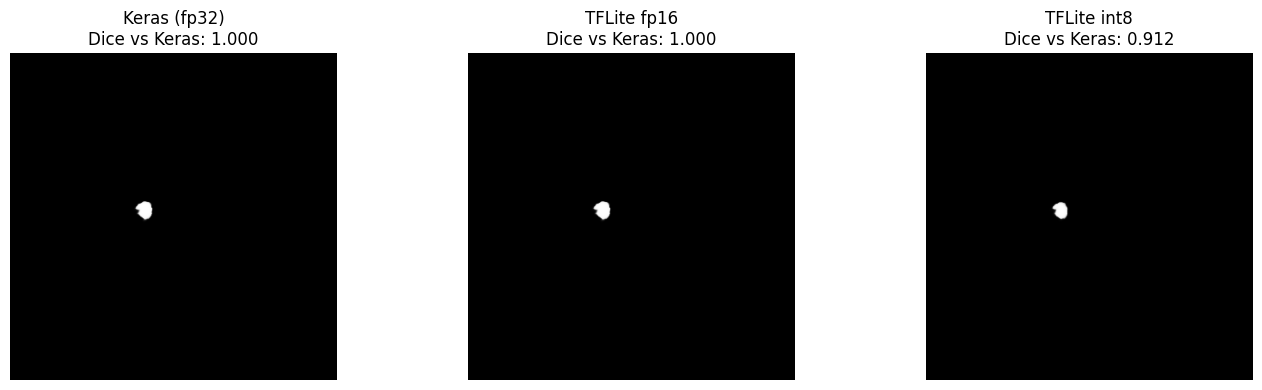

Wound dims (Keras) : {'length_cm': 0.16, 'width_cm': 0.14, 'depth_cm': None, 'area_cm2': 0.02}
Wound dims (int8)  : {'length_cm': 0.14, 'width_cm': 0.12, 'depth_cm': None, 'area_cm2': 0.01}


In [12]:
# VERIFY EXPORTED TFLITE  (run interpreters, compare against Keras output)
def run_tflite(path, sample):
    interp = tf.lite.Interpreter(model_path=path)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]

    x = sample[None, ...]
    if inp['dtype'] == np.uint8:                      # int8 model: quantize input
        scale, zero = inp['quantization']
        x = np.clip(x / scale + zero, 0, 255).astype(np.uint8) if scale else (x * 255).astype(np.uint8)
    else:
        x = x.astype(np.float32)

    interp.set_tensor(inp['index'], x)
    interp.invoke()
    y = interp.get_tensor(out['index'])[0, :, :, 0].astype(np.float32)
    if out['dtype'] == np.uint8:                      # dequantize output
        scale, zero = out['quantization']
        y = (y - zero) * scale if scale else y / 255.0
    return y


def dice_vs(a, b):
    a, b = a > 0.5, b > 0.5
    return 2.0 * np.sum(a & b) / (np.sum(a) + np.sum(b) + 1e-6)


sample = X_val[0]
keras_pred = model.predict(sample[None, ...], verbose=0)[0, :, :, 0]
preds = [
    keras_pred,
    run_tflite("model1_wound_fp16.tflite", sample),
    run_tflite("model1_wound_int8.tflite", sample),
]
titles = ["Keras (fp32)", "TFLite fp16", "TFLite int8"]

plt.figure(figsize=(14, 4))
for i, (t, p) in enumerate(zip(titles, preds)):
    plt.subplot(1, 3, i + 1)
    plt.title(f"{t}\nDice vs Keras: {dice_vs(p, keras_pred):.3f}")
    plt.imshow(p, cmap='gray'); plt.axis('off')
plt.tight_layout(); plt.show()

print("Wound dims (Keras) :", calculate_wound_dimensions_from_mask(keras_pred))
print("Wound dims (int8)  :", calculate_wound_dimensions_from_mask(preds[2]))
